In [2]:
#Import libaries
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:

tracks_historical_theo_corrected = pd.read_csv('../../../data/input/AR_tracks_proc_25y_s1990seed1v1.3modaccess_cm2_historical_corrected.csv')
tracks_historical_theo_corrected['datetime']=pd.to_datetime(tracks_historical_theo_corrected['ISO_TIME_POSIXct'])
tracks_historical_theo_corrected['SID']=tracks_historical_theo_corrected['SID'].str[:-3]

In [8]:
tracks_historical_theo_corrected.loc[lambda row:row["SID"]=="SYNT1990EP1",['SST','MSLP','nshr', 'T_strat']]

,SST,MSLP,nshr,T_strat
0,27.594202,1009.775909,0.867256,211.417969
1,27.594202,1009.775909,0.867256,211.417969
2,27.594202,1009.775909,0.867256,211.417969
3,27.491472,1010.135384,0.864635,211.556396
4,27.491472,1010.135384,0.864635,211.556396
...,...,...,...,...
151,28.773521,1009.106358,0.855057,210.190186
152,28.773521,1009.106358,0.855057,210.190186
153,28.773521,1009.106358,0.855057,210.190186
154,28.773521,1009.106358,0.855057,210.190186


In [4]:

tracks_historical_theo = pd.read_csv('../../../data/input/AR_tracks_proc_25y_s1990seed1v1.3modaccess_cm2_historical.csv')
tracks_historical_theo['datetime']=pd.to_datetime(tracks_historical_theo['ISO_TIME_POSIXct'])
tracks_historical_theo['SID']=tracks_historical_theo['SID'].str[:-3]

In [5]:
# Load tracks data
tracks_historical_dir = Path("../../../data/input/intensified_tracks_no_debias_historical_4/ACCESS-CM2/historical/").rglob("*.parquet")
files = [str(p) for p in tracks_historical_dir if p.is_file()]
tracks_historical_hamada = pd.concat(
    [
        pd.read_parquet(p)
        for p in files
    ]
).reset_index(drop=True)

In [6]:
# Load tracks data
tracks_historical_dir = Path("../../../data/input/bias_corrected_tracks/ACCESS-CM2/historical/").rglob("*.parquet")
files = [str(p) for p in tracks_historical_dir if p.is_file()]
tracks_historical_hamada_corrected = pd.concat(
    [
        pd.read_parquet(p)
        for p in files
    ]
).reset_index(drop=True)

In [7]:
df_sst = pd.merge(tracks_historical_theo_corrected.loc[lambda row:row['SID']=="SYNT1990EP1",:],
                  tracks_historical_hamada_corrected.loc[lambda row:row['SID']=="SYNT1990EP1",:],
                  how='inner',
                  on=['SID','datetime'])


Text(0, 0.5, 'Pangeo (Hamada)')

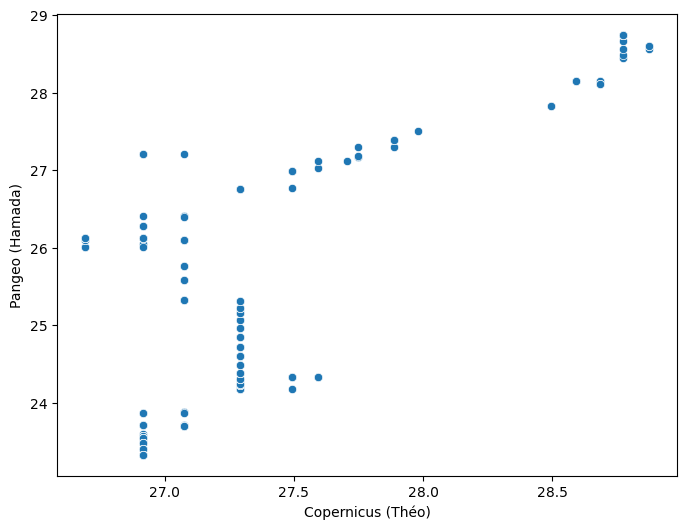

In [8]:
#Comparaison SST

df_sst = pd.merge(tracks_historical_theo_corrected.loc[lambda row:row['SID']=="SYNT1990EP1",['SID','datetime','LAT','LON','SST']],
                  tracks_historical_hamada.loc[lambda row:(row['SID']=="SYNT1990EP1"),['SID','datetime','lat_left','lon_left','SST']],
                  how='inner',
                  on=['SID','datetime'])

plt.figure(figsize=(8, 6)) # Optional: adjust figure size
sns.scatterplot(x='SST_x', y='SST_y', data=df_sst)
plt.xlabel('Copernicus (Théo)')
plt.ylabel('Pangeo (Hamada)')

In [81]:
df_sst.to_csv("test_temp.csv")

Text(0, 0.5, 'SST')

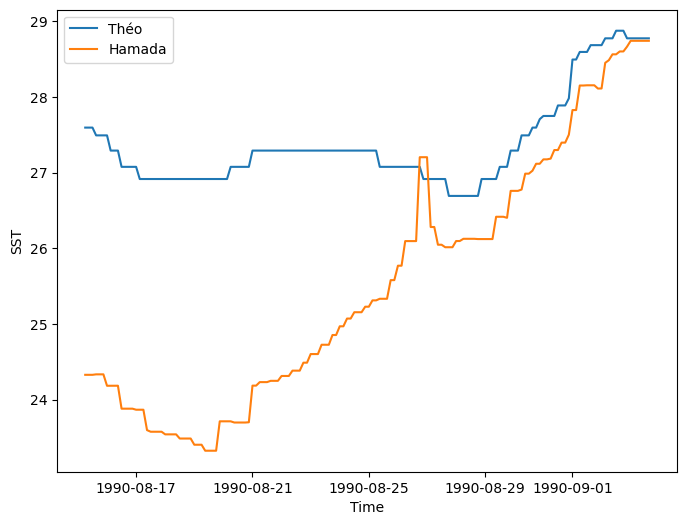

In [10]:
plt.figure(figsize=(8, 6)) # Optional: adjust figure size
sns.lineplot(x='datetime', y='SST_x', data=df_sst, label='Théo')
sns.lineplot(x='datetime', y='SST_y', data=df_sst, label='Hamada')
plt.xlabel('Time')
plt.ylabel('SST')

In [61]:
tracks_historical_hamada.loc[lambda row:(row['SID']=="SYNT1990EP1"),['SID','datetime','lat_left','lon_left','SST']]['SST'].max()


28.74077033996582

<Axes: xlabel='MSLP_x', ylabel='MSLP_y'>

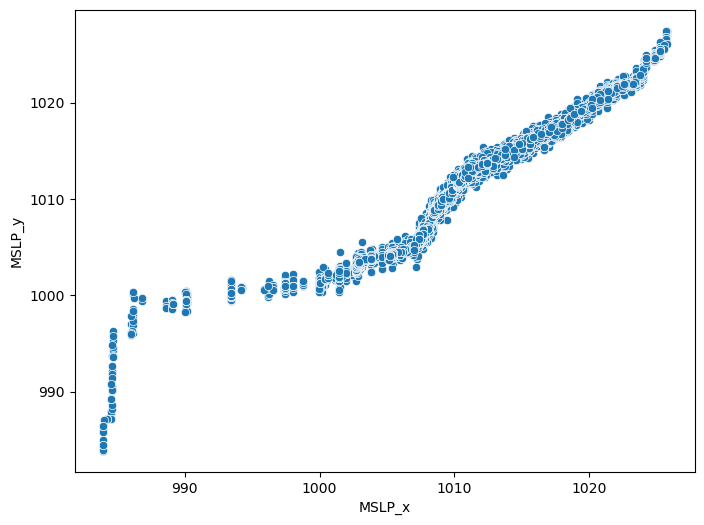

In [20]:
#Comparaison MLSP

df_mlsp = pd.merge(tracks_historical_theo_corrected.loc[:,['SID','datetime','LAT','LON','MSLP']],
                  tracks_historical_hamada.loc[lambda row:row['lon_left']>=0,['SID','datetime','lat_left','lon_left','MSLP']],
                  how='inner',
                  on=['SID','datetime'])

plt.figure(figsize=(8, 6)) # Optional: adjust figure size
sns.scatterplot(x='MSLP_x', y='MSLP_y', data=df_mlsp)

<Axes: xlabel='T_strat_x', ylabel='T_strat_y'>

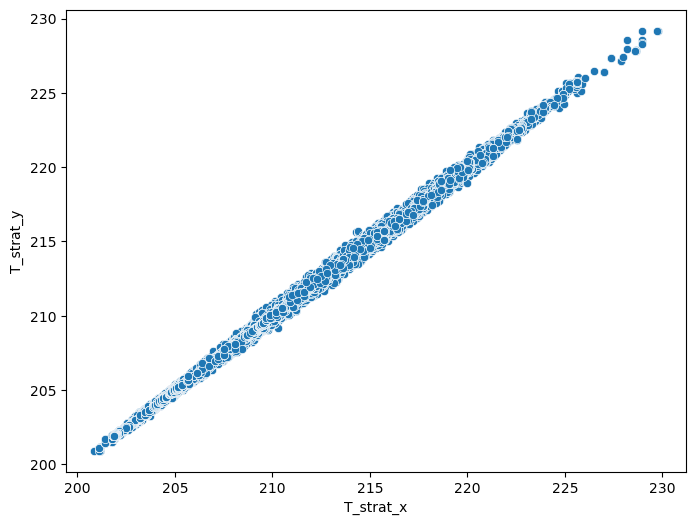

In [43]:
#Comparaison t strat

df_tstrat = pd.merge(tracks_historical_theo.loc[:,['SID','datetime','LAT','LON','T_strat']],
                  tracks_historical_hamada.loc[lambda row:row['lon_left']>0,['SID','datetime','lat_left','lon_left','T_strat']],
                  how='inner',
                  on=['SID','datetime'])

plt.figure(figsize=(8, 6)) # Optional: adjust figure size
sns.scatterplot(x='T_strat_x', y='T_strat_y', data=df_tstrat)

<Axes: xlabel='nshr_x', ylabel='nshr_y'>

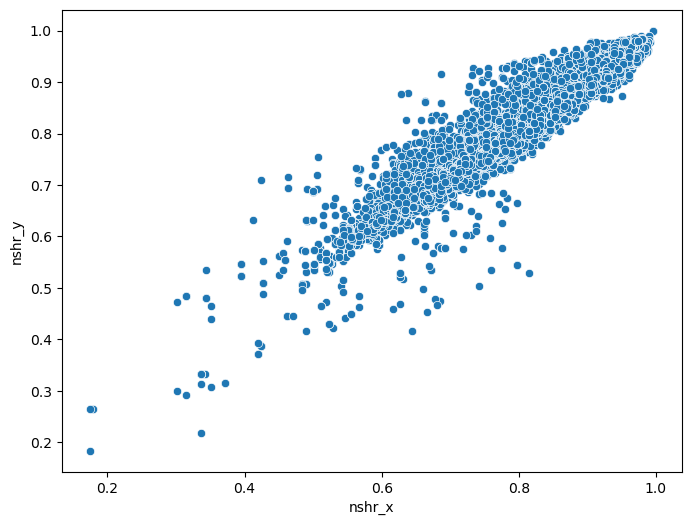

In [38]:
#Comparaison hur

df_nshr = pd.merge(tracks_historical_theo.loc[:,['SID','datetime','LAT','LON','nshr']],
                  tracks_historical_hamada.loc[lambda row:row['lon_left']>0,['SID','datetime','lat_left','lon_left','nshr']],
                  how='inner',
                  on=['SID','datetime'])

plt.figure(figsize=(8, 6)) # Optional: adjust figure size
sns.scatterplot(x='nshr_x', y='nshr_y', data=df_nshr)

In [63]:
tracks_historical_hamada['thermo_eff']=(273.15 + tracks_historical_hamada["tos"] - tracks_historical_hamada["ta"]) / (tracks_historical_hamada["tos"]+273.15)

<Axes: xlabel='thermo_eff_x', ylabel='thermo_eff_y'>

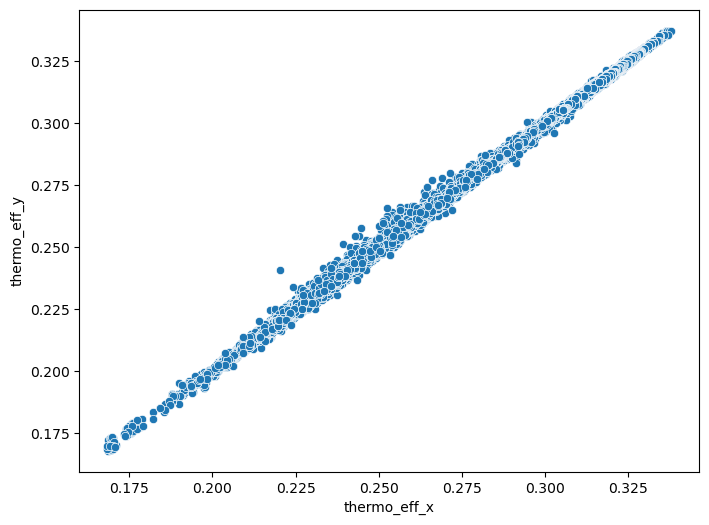

In [64]:
df_thermo_eff = pd.merge(tracks_historical_theo.loc[:,['SID','datetime','LAT','LON','thermo_eff']],
                  tracks_historical_hamada.loc[lambda row:row['lon_left']>0,['SID','datetime','lat_left','lon_left','thermo_eff']],
                  how='inner',
                  on=['SID','datetime'])

plt.figure(figsize=(8, 6)) # Optional: adjust figure size
sns.scatterplot(x='thermo_eff_x', y='thermo_eff_y', data=df_thermo_eff)